In [108]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## X_TRAIN - VIZ

In [109]:
x_train = pd.read_csv("../data/x_train_final.csv")
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0


In [110]:
x_train["nb_arrets"] = x_train.groupby(["train", "date"])["arret"].transform("count")
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,nb_arrets
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,5
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0,5
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0,5
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0,5
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0,19
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0,19
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0,19
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0,19


In [3]:
y_train = pd.read_csv("../data/y_train_final.csv")

In [4]:
x_train.describe()

# Unamed a tej

,Unnamed: 0.1,Unnamed: 0,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
count,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000
mean,333631.500000,333631.500000,18.277499,-0.170696,-0.167304,-0.176308,-0.163223,-0.173579,-0.174436
std,192622.669348,192622.669348,7.030424,1.976521,1.960416,1.926275,1.988527,2.643148,4.732999
min,0.000000,0.000000,7.000000,-160.000000,-160.000000,-160.000000,-160.000000,-1441.000000,-1441.000000
25%,166815.750000,166815.750000,12.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,333631.500000,333631.500000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,500447.250000,500447.250000,24.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,667263.000000,667263.000000,42.000000,14.000000,15.000000,15.000000,15.000000,15.000000,15.000000


In [5]:
# Nan values

x_train.isna().sum()

Unnamed: 0.1    0
Unnamed: 0      0
train           0
gare            0
date            0
arret           0
p2q0            0
p3q0            0
p4q0            0
p0q2            0
p0q3            0
p0q4            0
dtype: int64

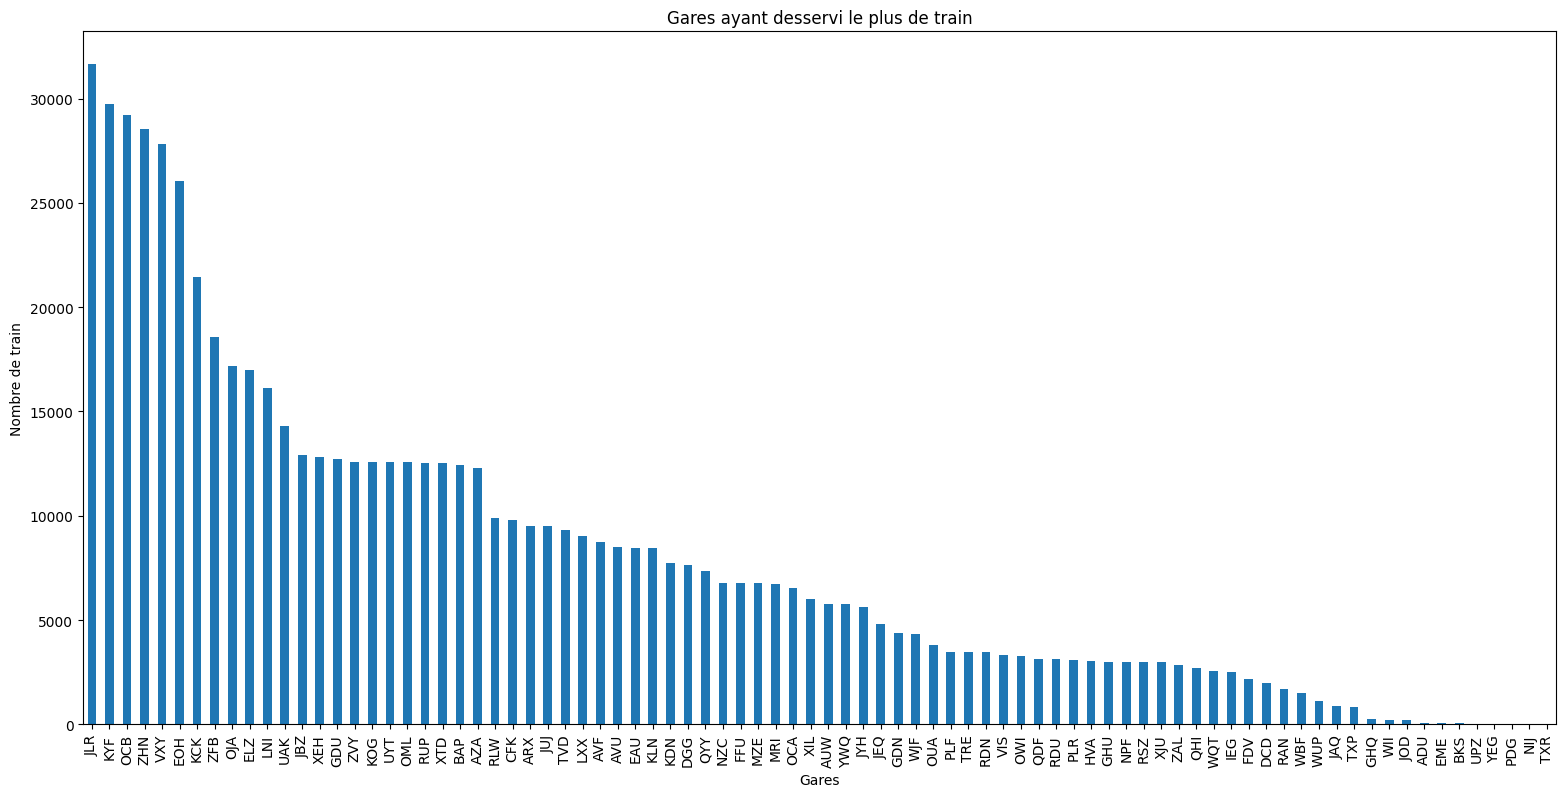

La gare ayant desservi le plus de train est  : JLR


In [6]:
plt.figure(figsize=(19,9))

x_train["gare"].value_counts().plot(kind="bar")
plt.title("Gares ayant desservi le plus de train")
plt.xlabel("Gares")
plt.ylabel("Nombre de train")
plt.show()

most_served_train_station = x_train["gare"].value_counts().sort_values(ascending=False).index[0]

print(f"La gare ayant desservi le plus de train est  : {most_served_train_station}")

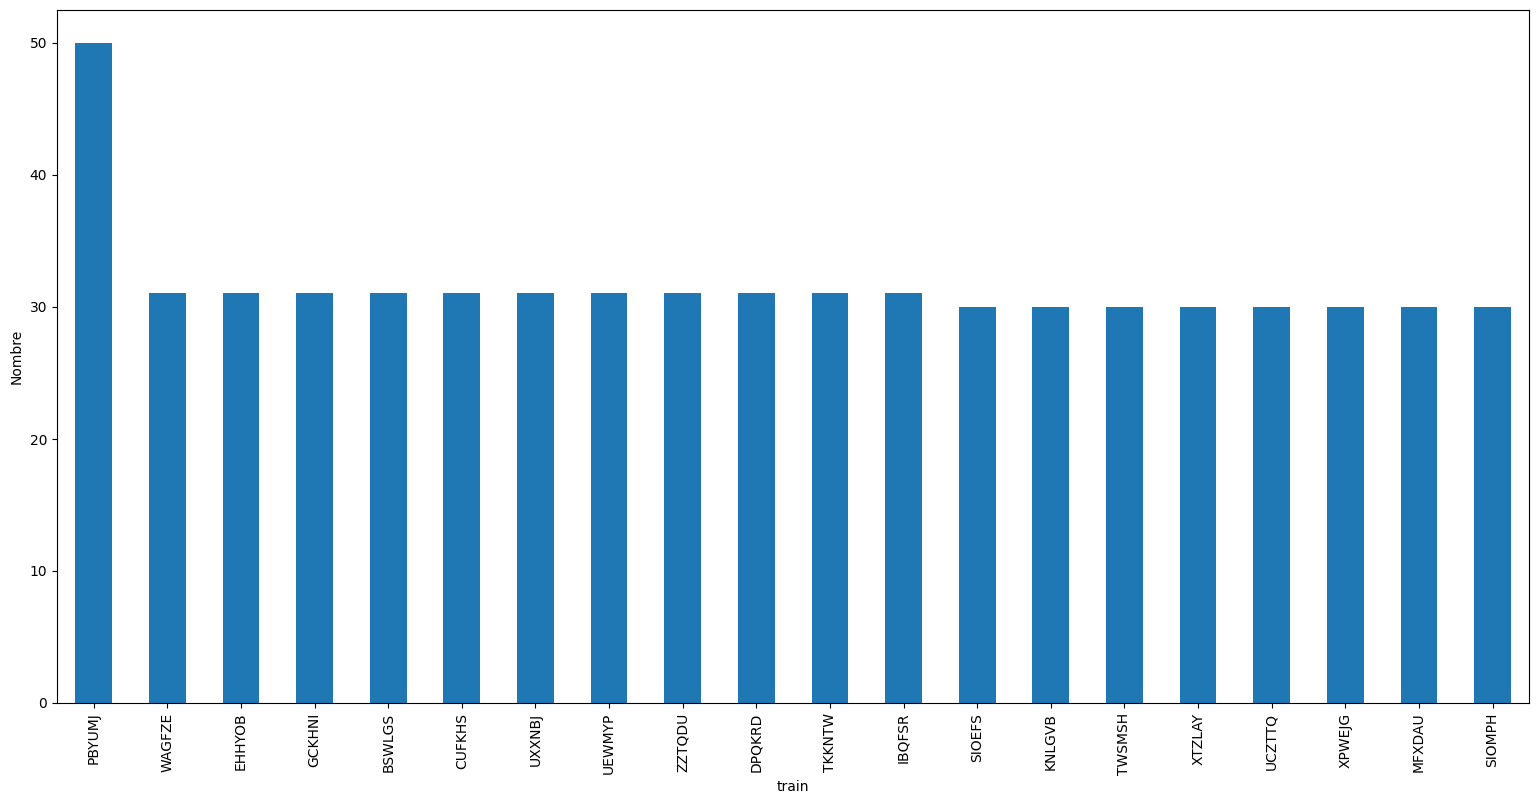

Le train le plus desservi est PBYUMJ !


In [7]:
plt.figure(figsize=(19,9))

x_train["train"].value_counts().head(20).plot(kind="bar")
plt.ylabel("Nombre")
plt.show()

most_served_train = x_train["train"].value_counts().sort_values(ascending=False).index[0]

print(f"Le train le plus desservi est {most_served_train} !")

In [8]:
x_train[(x_train["train"] == "PBYUMJ") & (x_train["gare"] == "JLR")] # Le train PBYUMJ est desservi deux fois sur la gare JLR

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
98693,98693,98693,PBYUMJ,JLR,2023-05-09,12,0.0,0.0,0.0,0.0,0.0,1.0
236402,236402,236402,PBYUMJ,JLR,2023-06-06,23,0.0,0.0,0.0,0.0,-1.0,1.0


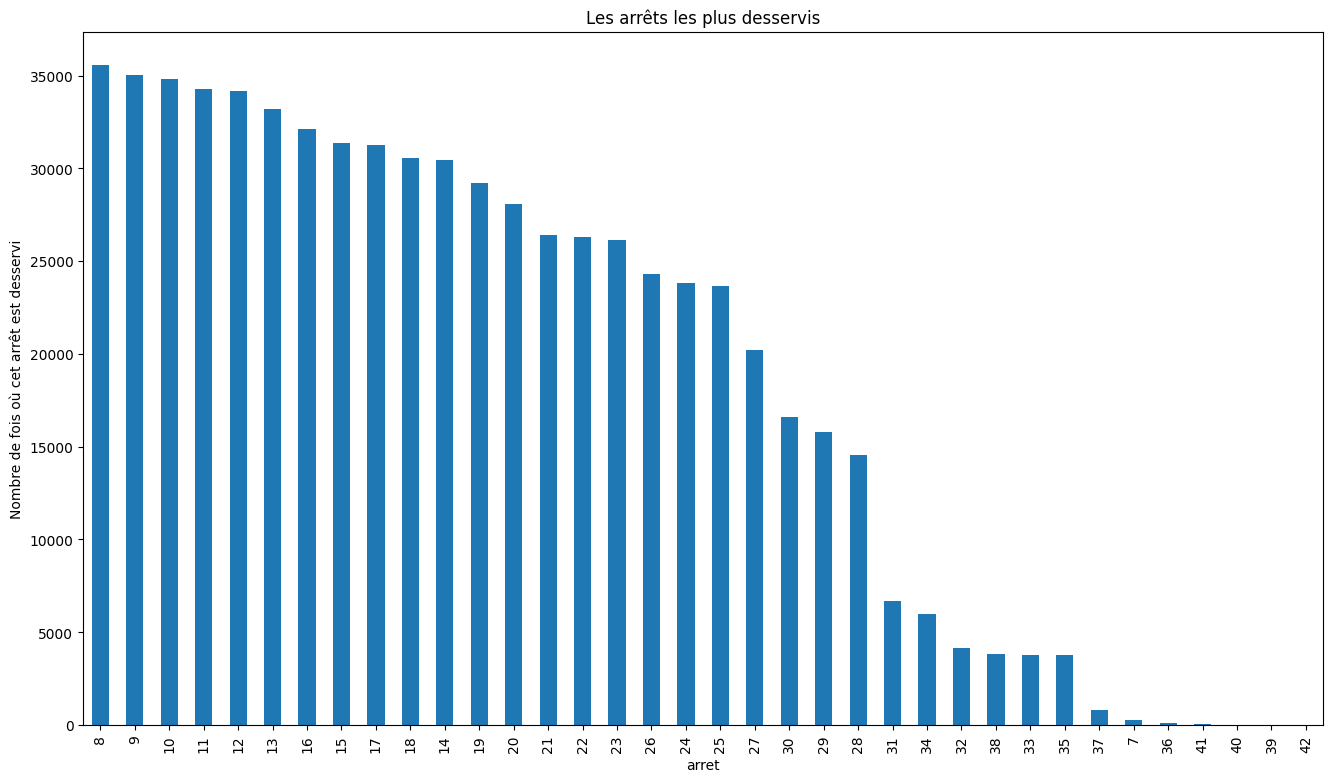

L'arrêt le plus desservi est le 8


In [9]:
plt.figure(figsize=(16,9))

x_train["arret"].value_counts().plot(kind="bar")
plt.title("Les arrêts les plus desservis")
plt.ylabel("Nombre de fois où cet arrêt est desservi")
plt.show()

most_served_stop = x_train['arret'].value_counts().sort_values(ascending=False).index[0]

print(f"L'arrêt le plus desservi est le {most_served_stop}")

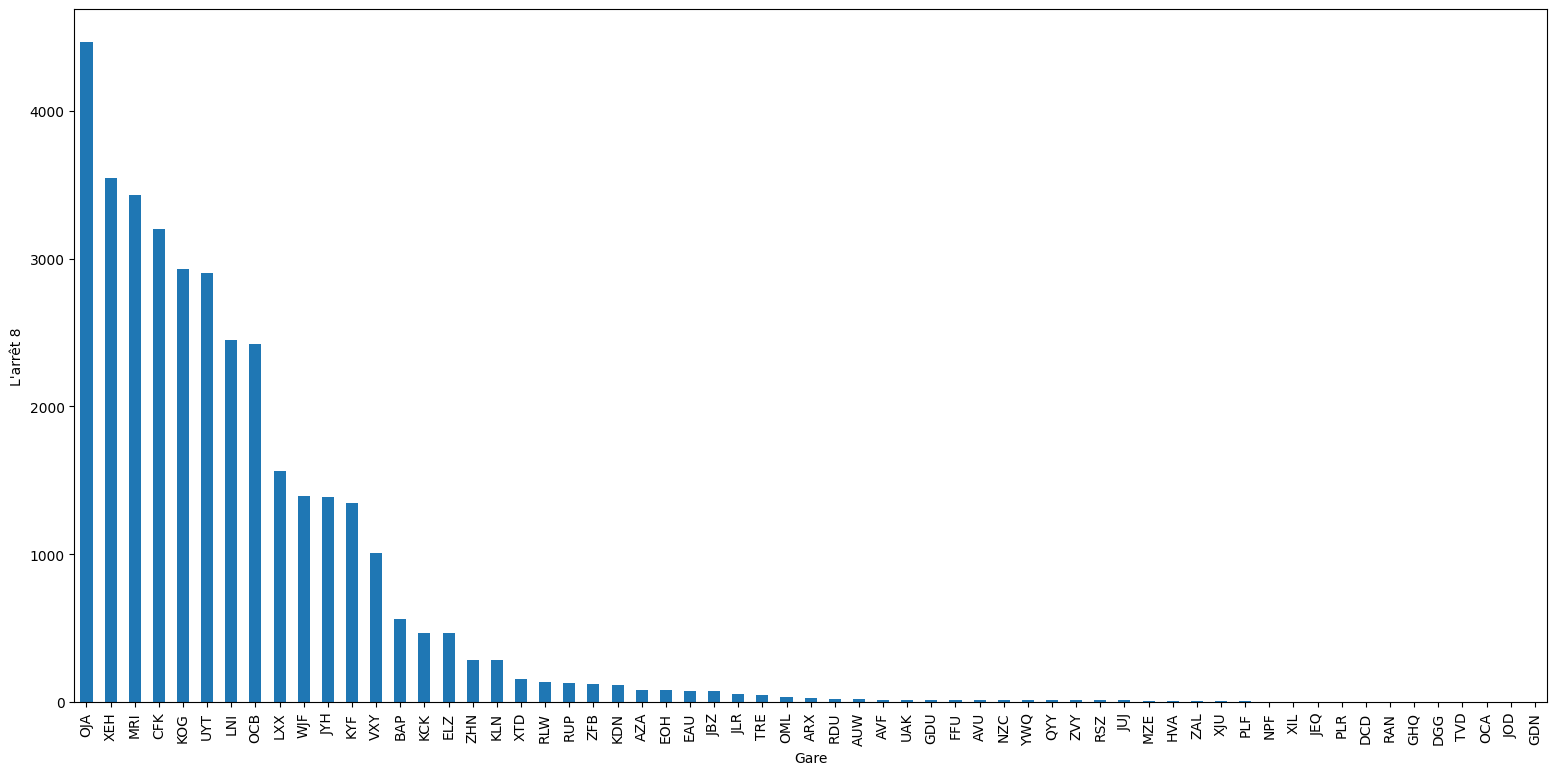

In [10]:
plt.figure(figsize=(19,9))
x_train[x_train["arret"] == 8]["gare"].value_counts().plot(kind="bar")
plt.xlabel("Gare")
plt.ylabel("L'arrêt 8")
plt.show()

In [11]:
x_train["date"]  = pd.to_datetime(x_train["date"])

In [12]:
x_train["year"] = x_train["date"].dt.year
x_train["month"] = x_train["date"].dt.month
x_train["day"] = x_train["date"].dt.day
x_train["day_of_week"] = x_train["date"].dt.dayofweek

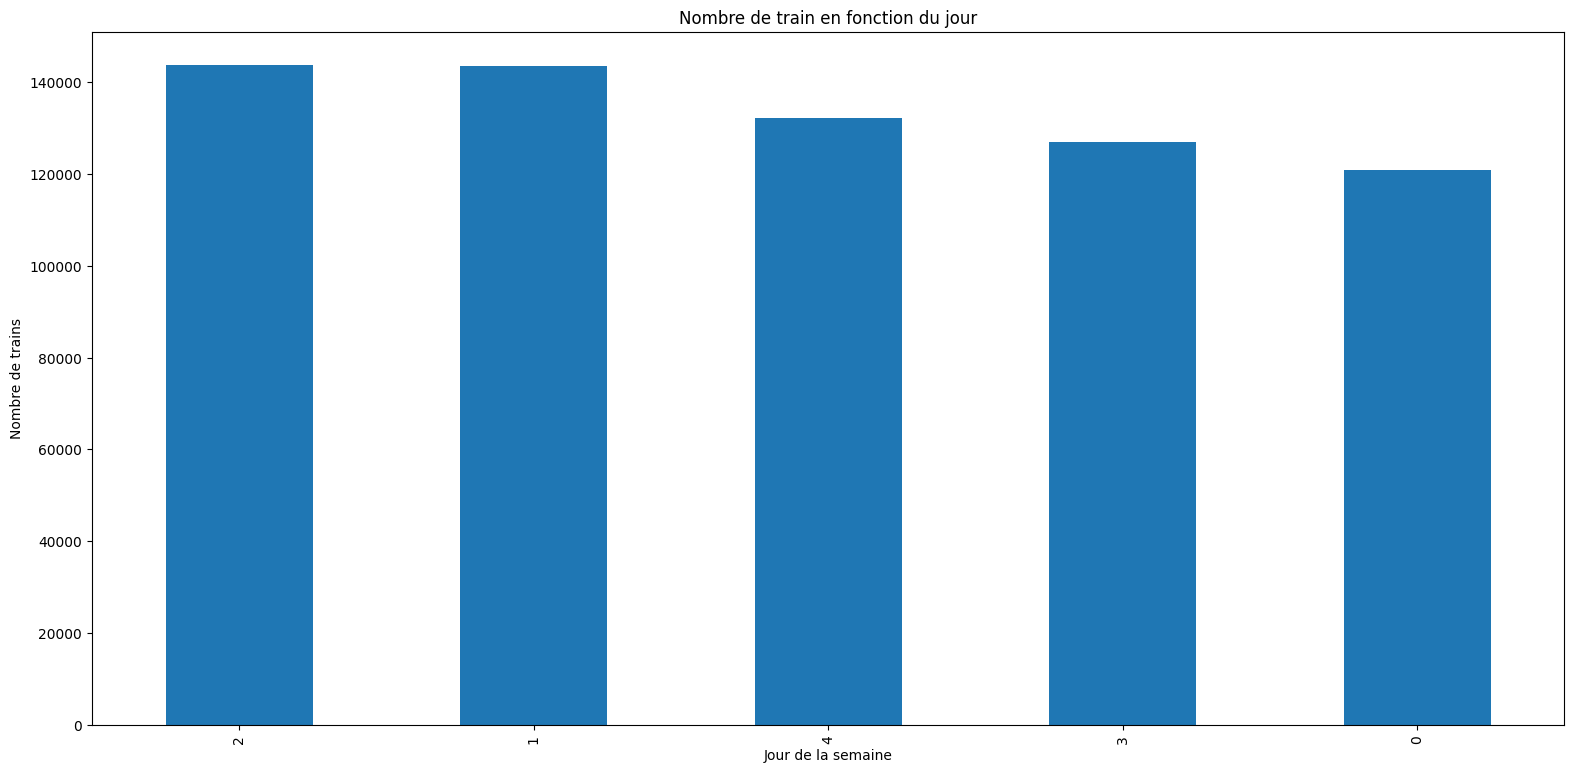

In [13]:
plt.figure(figsize=(19,9))

x_train["day_of_week"].value_counts().plot(kind="bar")
plt.title("Nombre de train en fonction du jour")
plt.xlabel("Jour de la semaine")
plt.ylabel("Nombre de trains")
plt.show()

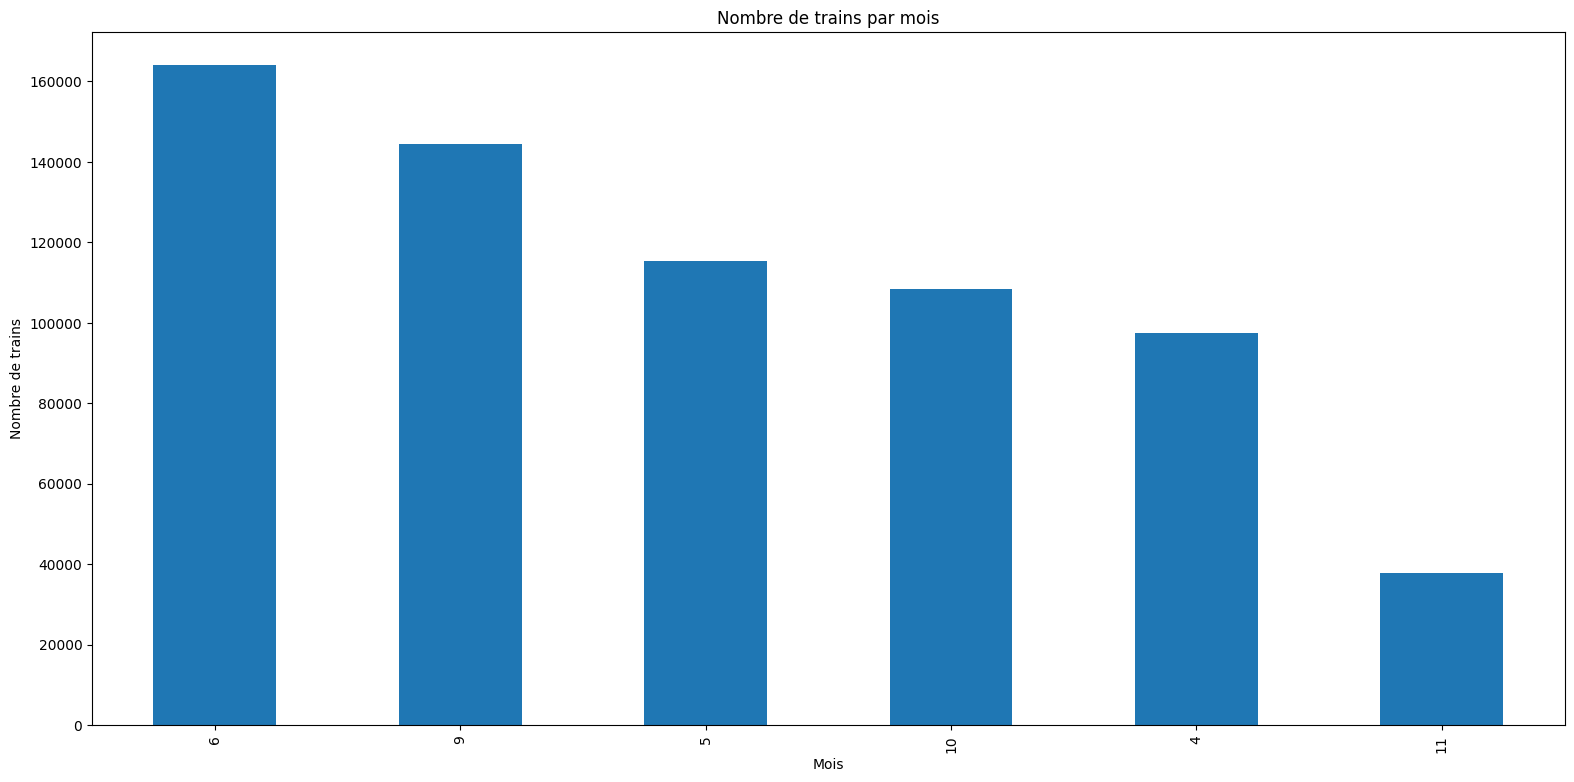

In [14]:
plt.figure(figsize=(19,9))

x_train["month"].value_counts().plot(kind="bar")
plt.title("Nombre de trains par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de trains")
plt.show()

In [15]:
# Encodage cyclique
x_train["month_sin"] = np.sin(2 * np.pi * x_train["month"] / 12)
x_train["month_cos"] = np.cos(2 * np.pi * x_train["month"] / 12)
x_train["day_of_week_sin"] = np.sin(2 * np.pi * x_train["day_of_week"] / 5)
x_train["day_of_week_cos"] = np.cos(2 * np.pi * x_train["day_of_week"] / 5)

In [16]:
x_train_cpy = x_train.drop(columns=["Unnamed: 0.1" , "Unnamed: 0" , "year" , "date" , "day_of_week","month" ,"day"])

In [17]:
x_train_cpy

,train,gare,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,day_of_week_cos
0,VBXNMF,KYF,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,0.866025,-0.500000,0.000000,1.000000
1,VBXNMF,JLR,9,0.0,0.0,0.0,1.0,0.0,1.0,0.866025,-0.500000,0.000000,1.000000
2,VBXNMF,EOH,10,-1.0,0.0,0.0,-1.0,0.0,0.0,0.866025,-0.500000,0.000000,1.000000
3,VBXNMF,VXY,11,-1.0,-1.0,0.0,2.0,-2.0,0.0,0.866025,-0.500000,0.000000,1.000000
4,VBXNMF,OCB,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0,0.866025,-0.500000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
667259,BFNJJK,DGG,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0,-0.500000,0.866025,-0.951057,0.309017
667260,BFNJJK,KDN,23,0.0,0.0,-1.0,1.0,0.0,0.0,-0.500000,0.866025,-0.951057,0.309017
667261,BFNJJK,TVD,24,1.0,0.0,0.0,-1.0,-3.0,-1.0,-0.500000,0.866025,-0.951057,0.309017
667262,BFNJJK,TXP,26,2.0,2.0,1.0,0.0,0.0,1.0,-0.500000,0.866025,-0.951057,0.309017


In [18]:
# Retard de train : p2q0 . Nous allons fixer la gare s à TVD . retard du train k-2 à la gare s

p2q0 = x_train_cpy[x_train_cpy["gare"] == "TVD"]["p2q0"]

mean_late = p2q0.mean()
max_late = np.abs(p2q0.min())
min_late = p2q0.max()

print(f"Nous avons en moyenne {mean_late} minutes de retard pour la gare TVD !")
print(f"Nous avons au maximum {max_late} minutes de retard pour la gare TVD ! ")
print(f"Nous avons au maximum {min_late} minutes d'avance pour la gare TVD ! ")

Nous avons en moyenne 0.38915675559841423 minutes de retard pour la gare TVD !
Nous avons au maximum 75.0 minutes de retard pour la gare TVD ! 
Nous avons au maximum 5.0 minutes d'avance pour la gare TVD ! 


In [19]:
# Retard du même train k pour toutes les gares qu'il a déja traversées. p0q2 = retard du train k à la gare s-2 . On fixe le train k : PBYUMJ

p0q2 = x_train_cpy[x_train_cpy["train"] == "PBYUMJ"]["p0q2"]

mean_late = p0q2.mean()
max_late = np.abs(p0q2.min())
min_late = p0q2.max()

print(f"Nous avons en moyenne {mean_late} minutes de retard pour le train PBYUMJ pour la gare s-2 !")
print(f"Nous avons au maximum {max_late} minutes de retard pour le train PBYUMJ pour la gare s-2 !")
print(f"Nous avons au maximum {min_late} minutes d'avance pour le train PBYUMJ pour la gare s-2 !")

Nous avons en moyenne -0.2 minutes de retard pour le train PBYUMJ pour la gare s-2 !
Nous avons au maximum 3.0 minutes de retard pour le train PBYUMJ pour la gare s-2 !
Nous avons au maximum 2.0 minutes d'avance pour le train PBYUMJ pour la gare s-2 !


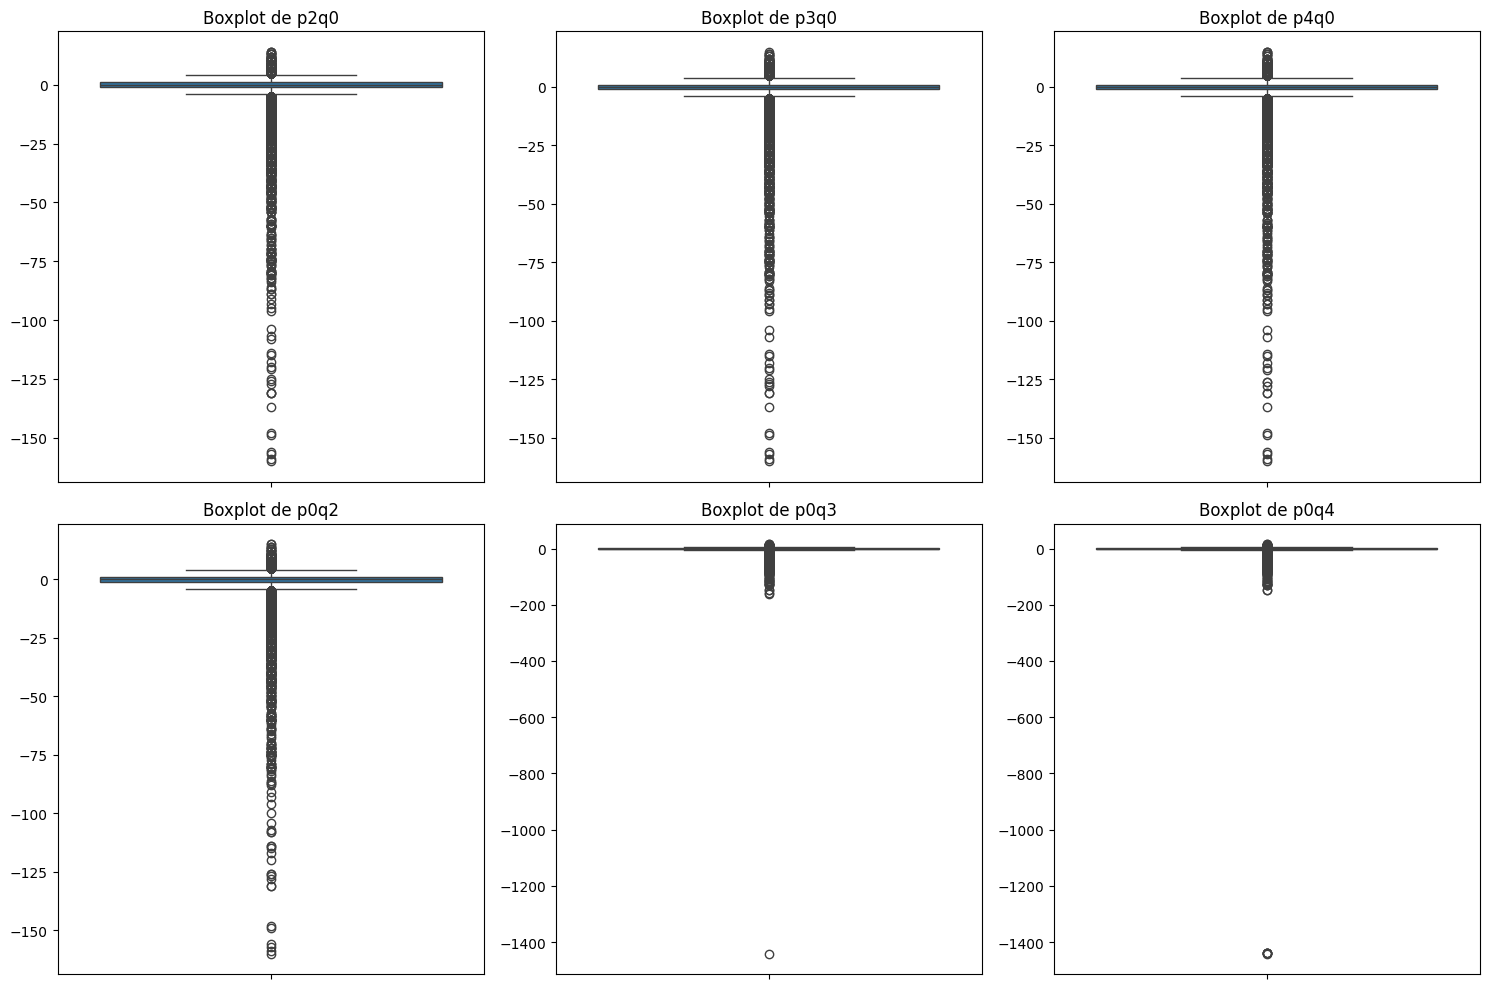

In [20]:
colonnes = ["p2q0","p3q0","p4q0","p0q2","p0q3","p0q4"]


fig, axes = plt.subplots(2, 3, figsize=(15, 10)) 

for ax, col in zip(axes.flatten(), colonnes):
    sns.boxplot(y=x_train_cpy[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")
    ax.set_ylabel("") 

plt.tight_layout()
plt.show()

In [26]:
x_train_cpy[x_train_cpy["p0q3"] <= -500]["p0q3"] # A remplacer par un -1 , la moyenne entre p0q2 et p0q4

315111   -1441.0
Name: p0q3, dtype: float64

In [22]:
x_train_cpy[x_train_cpy["p0q4"] <= -500] # # A remplacer par la moyenne entre p0q2 et p0q3

,train,gare,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,day_of_week_cos
115576,LRDJCC,GDN,21,0.0,1.0,1.0,0.0,0.0,-1440.0,5.000000e-01,-0.866025,-0.587785,-0.809017
153537,FTYMLQ,JLR,10,-1.0,-1.0,-1.0,0.0,0.0,-1438.0,5.000000e-01,-0.866025,-0.951057,0.309017
153561,OASJIF,GDN,21,-1.0,0.0,0.0,0.0,1.0,-1439.0,5.000000e-01,-0.866025,-0.951057,0.309017
315121,YQWYHB,AVF,14,0.0,0.0,-1.0,0.0,1.0,-1440.0,1.224647e-16,-1.000000,0.587785,-0.809017
315340,SBVADY,JLR,12,0.0,0.0,-1.0,0.0,0.0,-1440.0,1.224647e-16,-1.000000,0.587785,-0.809017
322157,NOATQT,VXY,15,-1.0,0.0,0.0,0.0,-2.0,-1441.0,1.224647e-16,-1.000000,0.587785,-0.809017


In [125]:
x_test

,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,day,day_of_week
0,0,ZPQEKP,VXY,2023-11-13,12,0.0,0.0,-2.0,-4.0,-2.0,-4.0,13,0
1,1,KIQSRA,VXY,2023-11-13,12,0.0,0.0,-1.0,1.0,-1.0,0.0,13,0
2,2,QQJYYT,VXY,2023-11-13,12,0.0,1.0,-1.0,1.0,-1.0,1.0,13,0
3,3,FVKYMZ,VXY,2023-11-13,12,0.0,0.0,-1.0,-1.0,0.0,-1.0,13,0
4,4,GXNZBY,AZA,2023-11-13,12,1.0,-2.0,0.0,0.0,0.0,0.0,13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20652,20652,GZDMWQ,OJA,2023-12-22,24,-1.0,-1.0,1.0,0.0,1.0,0.0,22,4
20653,20653,DRJDTW,KLN,2023-12-22,12,0.0,0.0,0.0,0.0,0.0,0.0,22,4
20654,20654,DRJDTW,KCK,2023-12-22,18,1.0,-2.0,0.0,-1.0,-1.0,-2.0,22,4
20655,20655,DRJDTW,OJA,2023-12-22,24,-2.0,-2.0,1.0,0.0,0.0,1.0,22,4


In [118]:
x_train_cpy.groupby("train")["arret"].count()["LZOAEF"]

np.int64(21)

## ## Y_TRAIN - VIZ

In [23]:
y_train = pd.read_csv("../data/y_train_final.csv")
y_train = y_train.drop(columns=["Unnamed: 0"])

In [86]:
y_train

,p0q0
0,-1.0
1,-1.0
2,-1.0
3,1.0
4,3.0
...,...
667259,1.0
667260,2.0
667261,2.0
667262,1.0


In [25]:
y_train.describe()

,p0q0
count,667264.000000
mean,-0.159950
std,1.987872
min,-160.000000
25%,-1.000000
50%,0.000000
75%,1.000000
max,15.000000


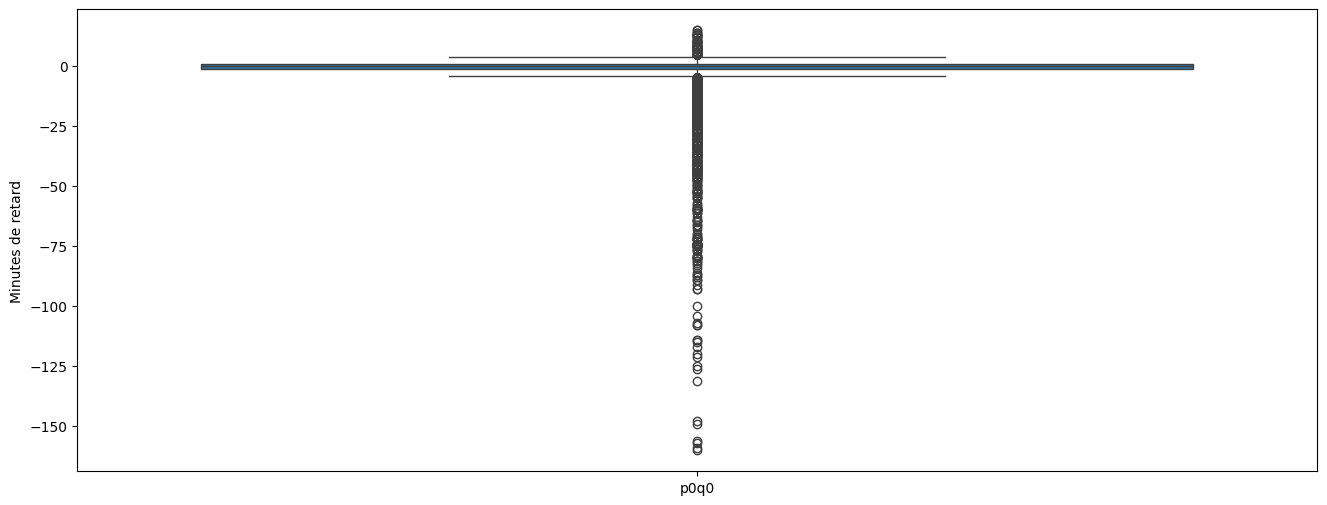

In [24]:
plt.figure(figsize=(16,6))
sns.boxplot(y_train)
plt.ylabel("Minutes de retard")
plt.show()

In [29]:
x_test = pd.read_csv("../data/x_test_final.csv")

x_test

,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,ZPQEKP,VXY,2023-11-13,12,0.0,0.0,-2.0,-4.0,-2.0,-4.0
1,1,KIQSRA,VXY,2023-11-13,12,0.0,0.0,-1.0,1.0,-1.0,0.0
2,2,QQJYYT,VXY,2023-11-13,12,0.0,1.0,-1.0,1.0,-1.0,1.0
3,3,FVKYMZ,VXY,2023-11-13,12,0.0,0.0,-1.0,-1.0,0.0,-1.0
4,4,GXNZBY,AZA,2023-11-13,12,1.0,-2.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
20652,20652,GZDMWQ,OJA,2023-12-22,24,-1.0,-1.0,1.0,0.0,1.0,0.0
20653,20653,DRJDTW,KLN,2023-12-22,12,0.0,0.0,0.0,0.0,0.0,0.0
20654,20654,DRJDTW,KCK,2023-12-22,18,1.0,-2.0,0.0,-1.0,-1.0,-2.0
20655,20655,DRJDTW,OJA,2023-12-22,24,-2.0,-2.0,1.0,0.0,0.0,1.0


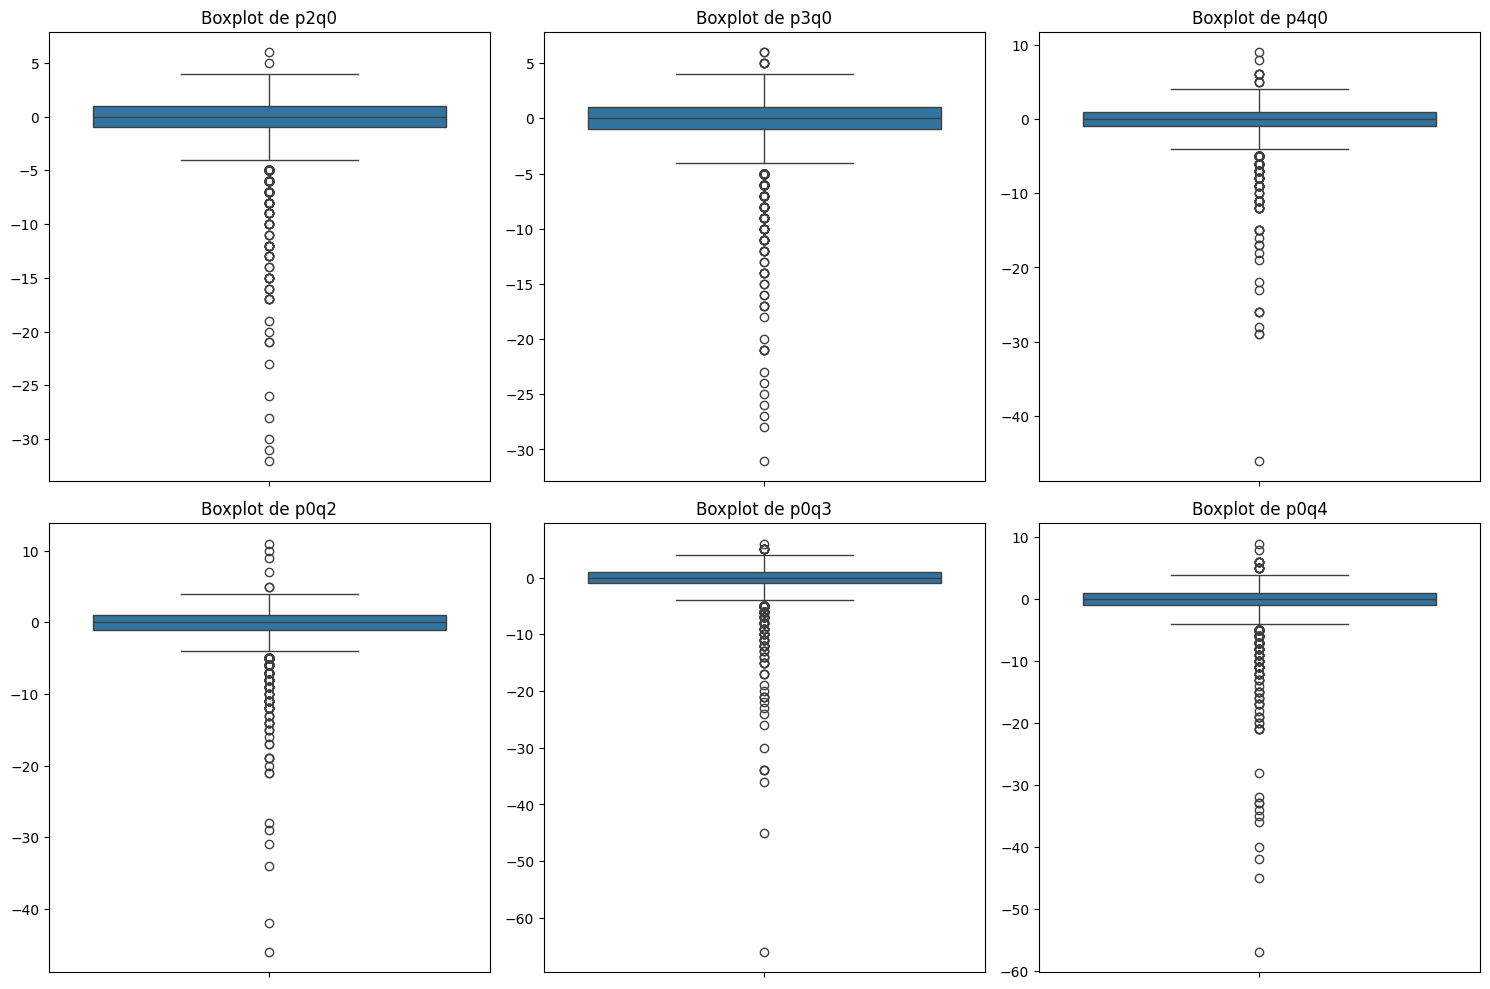

In [ ]:
colonnes = ["p2q0","p3q0","p4q0","p0q2","p0q3","p0q4"]


fig, axes = plt.subplots(2, 3, figsize=(15, 10)) 

for ax, col in zip(axes.flatten(), colonnes):
    sns.boxplot(y=x_test[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")
    ax.set_ylabel("") 

plt.tight_layout()
plt.show()

# PAS DE VALEUR ABERRANTE POUR X_TEST